# Bank Marketing Campaign Analysis 

## Libraries

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

##  Load Data

In [31]:
df = pd.read_csv("bank.csv")
print(df.shape) 

(11162, 17)


In [32]:
# Preview the first 5 rows to get a feel for the data
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [33]:
# Check for 'unknown' strings in the dataset before cleaning
# This dataset uses 'unknown' instead of actual null values
print("Unknown values before cleaning:")
print((df == 'unknown').sum())

Unknown values before cleaning:
age             0
job            70
marital         0
education     497
default         0
balance         0
housing         0
loan            0
contact      2346
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     8326
deposit         0
dtype: int64


In [34]:
# Check how many clients were contacted more than 20 times
# These are extreme outliers that could skew the analysis
print("Campaign outliers above 20:")
print((df['campaign'] > 20).sum()) 

Campaign outliers above 20:
42


In [35]:
# Check for extreme balance values beyond ±3 standard deviations
# These outliers could distort the analysis if left uncleaned
mean_b, std_b = df['balance'].mean(), df['balance'].std()
print("Balance outliers beyond ±3 std:")
print(((df['balance'] > mean_b + 3*std_b) | (df['balance'] < mean_b - 3*std_b)).sum())

Balance outliers beyond ±3 std:
173


## Data Cleaning

In [36]:
# Replace 'unknown' with NaN
unknown_cols = ['job', 'education', 'contact', 'poutcome']
for col in unknown_cols:
    df[col] = df[col].replace('unknown', pd.NA)

# Replace pdays -1 with NaN
df['pdays'] = df['pdays'].replace(-1, pd.NA)

# Cap campaign outliers at 20
df['campaign'] = df['campaign'].clip(upper=20)

# Save mean and std BEFORE clipping balance
mean_b, std_b = df['balance'].mean(), df['balance'].std()
df['balance'] = df['balance'].clip(lower=mean_b - 3*std_b, upper=mean_b + 3*std_b)

# Encode target as binary
df['subscribed'] = (df['deposit'] == 'yes').astype(int)

# Overall subscription rate
sub_rate = df['subscribed'].mean() * 100
print(f"Subscription rate: {sub_rate:.1f}%")

Subscription rate: 47.4%


In [37]:
# Verify the 'unknown' strings have been properly converted to NaN
# These are intentional nulls — not data quality issues
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age              0
job             70
marital          0
education      497
default          0
balance          0
housing          0
loan             0
contact       2346
day              0
month            0
duration         0
campaign         0
pdays         8324
previous         0
poutcome      8326
deposit          0
subscribed       0
dtype: int64


In [38]:
# Confirm outlier capping worked correctly — both should be 0
print("Campaign outliers remaining:", (df['campaign'] > 20).sum()) 
print("Balance outliers remaining:", ((df['balance'] > mean_b + 3*std_b) | (df['balance'] < mean_b - 3*std_b)).sum())

Campaign outliers remaining: 0
Balance outliers remaining: 0


In [39]:
# Check for any duplicate rows in the dataset
print("Duplicates:", df.duplicated().sum())  # 0                 

Duplicates: 0


In [40]:
# Confirm target column encoded correctly
print("\nSubscribed value counts:")
print(df['subscribed'].value_counts())


Subscribed value counts:
subscribed
0    5873
1    5289
Name: count, dtype: int64


In [41]:
# Confirm dataset shape after cleaning
print("\nShape after cleaning:", df.shape) 


Shape after cleaning: (11162, 18)


In [42]:
# Confirm pdays -1 is gone
print("\npdays -1 remaining:", (df['pdays'] == -1).sum()) 


pdays -1 remaining: 0


## Colors & Style

In [43]:
plt.style.use('dark_background')

ACCENT = "#00C9A7"  # teal  — above average
WARN   = "#FF6B6B"  # red   — reference line
BLUE   = "#2E4A6A"  # navy  — below average bars

## Exploratory Data Analysis

### Which job types are most likely to subscribe to a term deposit?

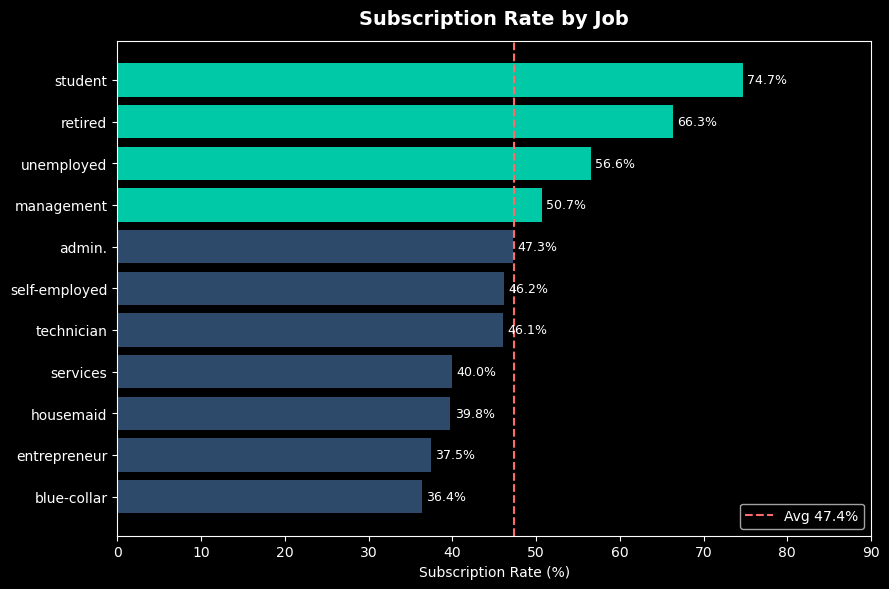

In [44]:
job_rate = (df.dropna(subset=['job'])
              .groupby('job')['subscribed']
              .mean()
              .sort_values() * 100)

colors = [ACCENT if v >= sub_rate else BLUE for v in job_rate]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(job_rate.index, job_rate.values, color=colors)
ax.axvline(sub_rate, color=WARN, linestyle='--', linewidth=1.5,
           label=f'Avg {sub_rate:.1f}%')

for bar, val in zip(bars, job_rate.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='white')

ax.set_title("Subscription Rate by Job", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Subscription Rate (%)")
ax.set_xlim(0, 90)
ax.legend()
plt.tight_layout()
plt.show()

#### Insight
- Students (74.7%) and retirees (66.3%) are the highest converting segments.

- Blue-collar (36.4%) and entrepreneurs (37.5%) are the hardest to convert.

- Target students and retirees first in future campaigns.

### Which months yield the highest subscription rates?

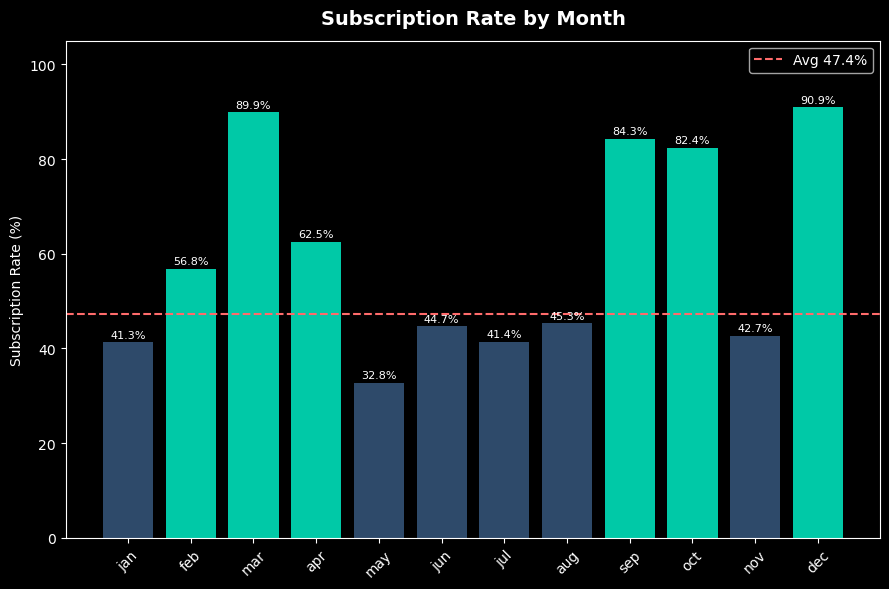

In [45]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['subscribed'].mean() * 100
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])

colors2 = [ACCENT if v >= sub_rate else BLUE for v in month_rate]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(month_rate.index, month_rate.values, color=colors2)
ax.axhline(sub_rate, color=WARN, linestyle='--', linewidth=1.5,
           label=f'Avg {sub_rate:.1f}%')

for bar, val in zip(bars, month_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', fontsize=8, color='white')

ax.set_title("Subscription Rate by Month", fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel("Subscription Rate (%)")
ax.set_ylim(0, 105)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Insight
- March (89.9%), December (90.9%) and September (84.3%) are the best months to run campaigns.

- May is the worst month at only 32.8% despite likely being the busiest.

- Concentrate campaigns in Q4 and March for maximum conversion.

### Do customers with higher account balances subscribe more?

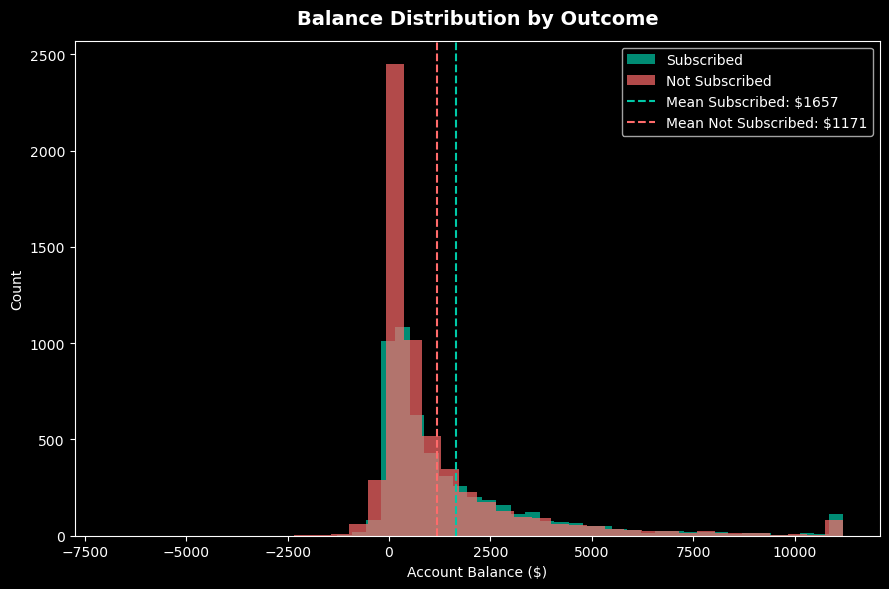

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(df[df['subscribed']==1]['balance'], bins=40, alpha=0.7,
        color=ACCENT, label='Subscribed')
ax.hist(df[df['subscribed']==0]['balance'], bins=40, alpha=0.7,
        color=WARN, label='Not Subscribed')

# Add mean lines
ax.axvline(df[df['subscribed']==1]['balance'].mean(), color=ACCENT,
           linestyle='--', linewidth=1.5, label=f'Mean Subscribed: ${df[df["subscribed"]==1]["balance"].mean():.0f}')
ax.axvline(df[df['subscribed']==0]['balance'].mean(), color=WARN,
           linestyle='--', linewidth=1.5, label=f'Mean Not Subscribed: ${df[df["subscribed"]==0]["balance"].mean():.0f}')

ax.set_title("Balance Distribution by Outcome", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Account Balance ($)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [47]:
yes = df[df['subscribed']==1]['balance']
no  = df[df['subscribed']==0]['balance']

print("Mean balance:")
print(f"  Subscribed:     ${yes.mean():.0f}")
print(f"  Not Subscribed: ${no.mean():.0f}")

print("\nMedian balance:")
print(f"  Subscribed:     ${yes.median():.0f}")
print(f"  Not Subscribed: ${no.median():.0f}")

print("\nBalance over $1,000:")
print(f"  Subscribed:     {(yes > 1000).mean()*100:.1f}%")
print(f"  Not Subscribed: {(no > 1000).mean()*100:.1f}%")

Mean balance:
  Subscribed:     $1657
  Not Subscribed: $1171

Median balance:
  Subscribed:     $733
  Not Subscribed: $414

Balance over $1,000:
  Subscribed:     42.5%
  Not Subscribed: 30.5%


#### Insight
- Subscribers have a higher mean balance ($1,657 vs $1,171) and median balance ($733 vs $414).

- 42.5% of subscribers have a balance over $1,000 vs only 30.5% of non-subscribers

- Customers with higher balances are more likely to invest — target higher balance segments.

#### Does being contacted in a previous campaign affect subscription?

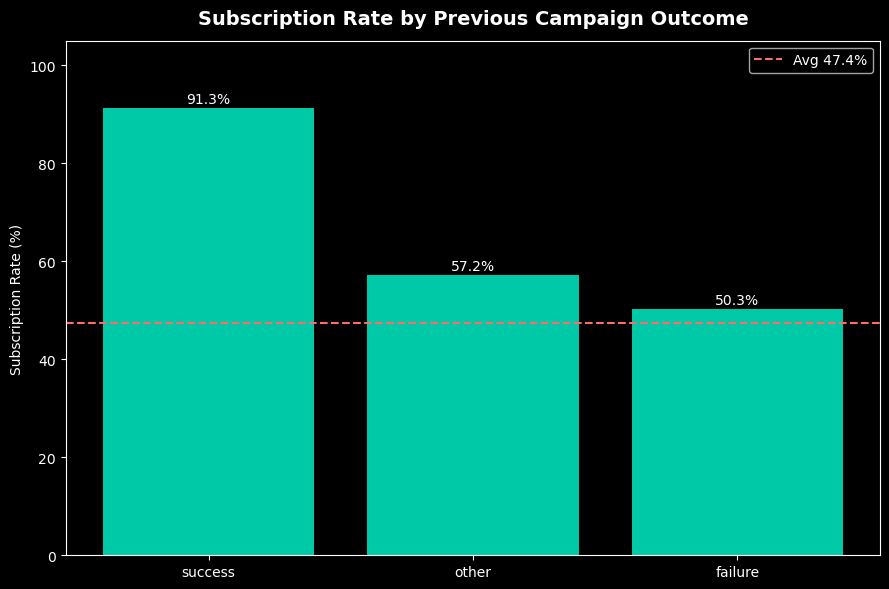

In [48]:
pout_rate = (df.dropna(subset=['poutcome'])
               .groupby('poutcome')['subscribed']
               .mean()
               .sort_values(ascending=False) * 100)

colors4 = [ACCENT if v >= sub_rate else BLUE for v in pout_rate]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(pout_rate.index, pout_rate.values, color=colors4)
ax.axhline(sub_rate, color=WARN, linestyle='--', linewidth=1.5,
           label=f'Avg {sub_rate:.1f}%')

for bar, val in zip(bars, pout_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', fontsize=10, color='white')

ax.set_title("Subscription Rate by Previous Campaign Outcome",
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel("Subscription Rate (%)")
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

#### Insight
- Customers who said yes before convert at 91.3% — the highest rate in the dataset.

- Even customers with other previous outcomes still convert at 57.2%, above the 47.4% average.

- Always re-target past subscribers first — they are the easiest to convert.

### Does age play a role in whether a customer subscribes?

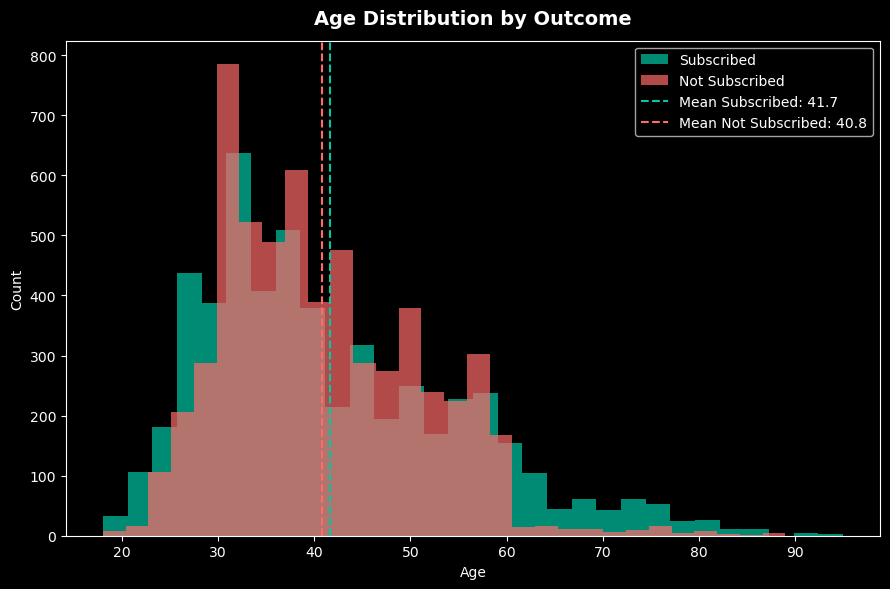

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(df[df['subscribed']==1]['age'], bins=30, alpha=0.7,
        color=ACCENT, label='Subscribed')
ax.hist(df[df['subscribed']==0]['age'], bins=30, alpha=0.7,
        color=WARN, label='Not Subscribed')

# Add mean lines
ax.axvline(df[df['subscribed']==1]['age'].mean(), color=ACCENT,
           linestyle='--', linewidth=1.5, label=f'Mean Subscribed: {df[df["subscribed"]==1]["age"].mean():.1f}')
ax.axvline(df[df['subscribed']==0]['age'].mean(), color=WARN,
           linestyle='--', linewidth=1.5, label=f'Mean Not Subscribed: {df[df["subscribed"]==0]["age"].mean():.1f}')

ax.set_title("Age Distribution by Outcome", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
print("Average age:")
print(f"  Subscribed:     {df[df['subscribed']==1]['age'].mean():.1f}")
print(f"  Not Subscribed: {df[df['subscribed']==0]['age'].mean():.1f}")

print("\nAge breakdown:")
print(f"  Under 30:  {(df['age'] < 30).mean()*100:.1f}%")
print(f"  30 to 60:  {((df['age'] >= 30) & (df['age'] <= 60)).mean()*100:.1f}%")
print(f"  Over 60:   {(df['age'] > 60).mean()*100:.1f}%")

Average age:
  Subscribed:     41.7
  Not Subscribed: 40.8

Age breakdown:
  Under 30:  13.9%
  30 to 60:  80.6%
  Over 60:   5.5%


#### Insight
- The average age is almost identical between both groups — 41.7 for subscribers vs 40.8 for non-subscribers.

- The majority of customers (80.6%) are between 30 and 60 years old across both groups.

- Age alone is not a useful predictor of subscription — job type and account balance matter far more.

## Summary

This analysis explored 11,162 customer records from a Portuguese bank's telemarketing campaign to identify which customers are most likely to subscribe to a term deposit.
The key takeaways are:

- Who to target — students, retirees and previous subscribers

- When to call — March, September and December

- What matters — account balance and call quality, not age

If the bank applies these findings to future campaigns, they can significantly improve conversion rates while reducing wasted outreach on low-converting segments.

#### Limitations

- The dataset only covers one bank in Portugal so findings may not apply universally

- The data is from one campaign period and trends may have changed over time

- Digital and social media channels are not represented in this data

#### What I Would Do Next

- Build a machine learning model to predict which customers will subscribe

- Analyze the effect of call duration more deeply

- Segment customers further by combining job type and balance together